# Inference Visualization (Shared Pipeline)

This notebook reproduces the denoising visualization workflow of `notebooks/inference_visualization.ipynb`, but uses the shared code path used by training/evaluation:
- `CelebA_DataSet`
- `Puzzle_Dataset_ROT`
- `Eff_GAT` checkpoint loading
- `GNN_Diffusion.reverse_step` for reverse diffusion

The reverse process is still unrolled here because visualization needs the intermediate states, but the schedule and reverse update come from `GNN_Diffusion` instead of being duplicated manually.

In [265]:
from pathlib import Path
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import transforms as mpl_transforms
import imageio.v2 as imageio
import torch
import torch_geometric
from scipy.optimize import linear_sum_assignment

if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise RuntimeError("Could not locate project root with a src/ directory.")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataset_celeb import CelebA_DataSet
from puzzle_dataset import Puzzle_Dataset_ROT
from gnn_diffusion import (
    GNN_Diffusion,
    split_pose,
    piece_position_accuracy,
    piece_rotation_accuracy,
    rotation_error,
    position_error,
    )
from model.efficient_gat import Eff_GAT

In [ ]:
cfg = {
    "checkpoint": "outputs/checkpoints/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77.pt",
    "dataset_path": str(PROJECT_ROOT / "data" / "CelebA-HQ"),
    "split": "test",
    "batch_size": 1,
    "steps": None,
    # Set the puzzle size here. Use None to infer it from the checkpoint.
    "puzzle_size": 6,
    "visual_model": "resnet18equiv",
    "gnn_model": "transformer", #"exophormer",
    "degree": -1,
    "missing_percentage": 10,
    "num_samples": 1,
    "save_every": 2,
    "random_sample": True,
    # Set to an int (e.g., 42) for reproducible sampling; use None for a different sample each run.
    "random_seed": 2517,
    "prediction_only": False,
    "make_gif": True,
    "gif_fps": 6,
    "max_batches": 1,
    "output_dir": str(PROJECT_ROOT / "outputs" / "inference_steps"),
    # New inference controls
    "sampler": "ddim",  # "ddim" or "ddpm"
    "sampling_steps": 2,  # Used only for DDIM
    # When True, prints periodic progress while denoising so long runs do not look stuck.
    "verbose_progress": True,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if cfg["random_seed"] is not None:
    random.seed(cfg["random_seed"])
    np.random.seed(cfg["random_seed"])
    torch.manual_seed(cfg["random_seed"])
    print(f"Random seed fixed to {cfg['random_seed']} (reproducible sample order).")
else:
    print("Random seed not fixed (sample order will vary between runs).")

Using device: cuda
Random seed fixed to 2517 (reproducible sample order).


In [267]:
def resolve_checkpoint_path(checkpoint_arg: str) -> Path:
    candidate = Path(checkpoint_arg)
    if candidate.exists():
        return candidate.resolve()

    root_relative = PROJECT_ROOT / checkpoint_arg
    if root_relative.exists():
        return root_relative.resolve()

    matches = sorted((PROJECT_ROOT / "outputs" / "checkpoints").glob(f"**/{checkpoint_arg}"))
    if len(matches) == 1:
        return matches[0].resolve()

    raise FileNotFoundError(
        f"Checkpoint not found: {checkpoint_arg}. Provide absolute path, project-relative path, or checkpoint filename."
    )


def infer_steps_and_puzzle_size(checkpoint: dict, steps_cfg, puzzle_size_cfg):
    ckpt_cfg = checkpoint.get("config", {})

    if steps_cfg is None:
        steps = int(ckpt_cfg.get("steps", 300))
    else:
        steps = int(steps_cfg)

    if puzzle_size_cfg is None:
        raw = ckpt_cfg.get("puzzle_sizes", [6])
        puzzle_size = int(raw[0] if isinstance(raw, list) else raw)
    else:
        puzzle_size = int(puzzle_size_cfg)

    return steps, puzzle_size


def build_dataloader(dataset_path: str, split: str, puzzle_size: int, batch_size: int, degree: int, missing_percentage: int, random_sample: bool):
    is_train = split.lower() == "train"
    base_dataset = CelebA_DataSet(dataset_path, train=is_train)
    puzzle_dataset = Puzzle_Dataset_ROT(
        dataset=base_dataset,
        patch_per_dim=[(puzzle_size, puzzle_size)],
        augment=False,
        degree=degree,
        unique_graph=None,
        all_equivariant=False,
        random_dropout=False,
        missing_percentage=missing_percentage,
    )
    loader = torch_geometric.loader.DataLoader(
        puzzle_dataset,
        batch_size=batch_size,
        shuffle=random_sample,
    )
    return puzzle_dataset, loader


def build_model(checkpoint: dict, steps: int, visual_model: str, gnn_model: str, device: torch.device):
    model = Eff_GAT(
        steps=steps,
        input_channels=4,
        output_channels=4,
        n_layers=4,
        model=visual_model,
        architecture=gnn_model,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model

In [268]:
def compute_pose_metrics(pred_pose: torch.Tensor, gt_pose: torch.Tensor) -> dict:
    pred_pos, pred_rot = split_pose(pred_pose)
    gt_pos, gt_rot = split_pose(gt_pose)

    return {
        "position_accuracy": float(piece_position_accuracy(pred_pos, gt_pos).item()),
        "rotation_accuracy": float(piece_rotation_accuracy(pred_rot, gt_rot).item()),
        "position_error": float(position_error(pred_pos, gt_pos).item()),
        "rotation_error": float(rotation_error(pred_rot, gt_rot).item()),
    }


def format_metrics_caption(metrics: dict) -> str:
    return (
        f"Pos acc: {metrics['position_accuracy']:.3f} | "
        f"Rot acc: {metrics['rotation_accuracy']:.3f}\n"
        f"Pos err: {metrics['position_error']:.3f} | "
        f"Rot err: {metrics['rotation_error']:.3f}"
    )


def infer_patch_half_size(reference_pose: torch.Tensor) -> tuple[float, float]:
    xy = reference_pose[:, :2].detach().cpu()

    xs = torch.sort(torch.unique(xy[:, 0]))[0]
    ys = torch.sort(torch.unique(xy[:, 1]))[0]

    dx = float((xs[1] - xs[0]).item()) if len(xs) > 1 else 0.3
    dy = float((ys[1] - ys[0]).item()) if len(ys) > 1 else 0.3

    # Slight overlap avoids visible seams after rotation
    return 0.505 * dx, 0.505 * dy


def render_pose_exact(
    ax,
    patches: torch.Tensor,
    pose: torch.Tensor,
    title: str,
    half_w: float,
    half_h: float,
    title_color: str = "white",
):
    pose = pose.detach().cpu()
    patches = patches.detach().cpu().clamp(0, 1)

    xy = pose[:, :2]
    rot = pose[:, 2:4]

    theta = torch.atan2(rot[:, 1], rot[:, 0]).numpy()

    # Clean validity mask (avoid creating new tensors)
    valid = torch.isfinite(xy).all(dim=1) & torch.isfinite(rot).all(dim=1)

    xy = xy[valid]
    theta = theta[valid.numpy()]
    patches = patches[valid]

    for i in range(patches.shape[0]):
        img = patches[i].permute(1, 2, 0).numpy()

        x = float(xy[i, 0])
        y = float(xy[i, 1])

        im = ax.imshow(
            img,
            extent=[x - half_w, x + half_w, y - half_h, y + half_h],
            interpolation="bilinear",
            origin="lower",
        )

        im.set_transform(
            mpl_transforms.Affine2D().rotate_around(x, y, float(theta[i])) + ax.transData
        )

    ax.set_facecolor("black")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(1.2, -1.2)
    ax.set_aspect("equal")
    ax.set_title(title, color=title_color)
    ax.axis("off")


def show_step_figure(
    patches: torch.Tensor,
    gt_pose: torch.Tensor,
    pred_pose: torch.Tensor,
    puzzle_size: int,
    step_index: int,
    prediction_only: bool = False,
    metrics: dict | None = None,
):
    half_w, half_h = infer_patch_half_size(gt_pose)

    if prediction_only:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

        title = f"Predicted Reconstruction (step {step_index})"
        if metrics is not None:
            title = f"{title}\n{format_metrics_caption(metrics)}"

        render_pose_exact(ax, patches, pred_pose, title, half_w, half_h)

        fig.patch.set_facecolor("black")
        fig.tight_layout()
        return fig

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.patch.set_facecolor("black")

    render_pose_exact(axes[0], patches, gt_pose, "Ground Truth Target", half_w, half_h)

    pred_title = f"Predicted Reconstruction (step {step_index})"
    if metrics is not None:
        pred_title = f"{pred_title}\n{format_metrics_caption(metrics)}"

    render_pose_exact(axes[1], patches, pred_pose, pred_title, half_w, half_h)

    fig.tight_layout()
    return fig


def should_save_step(step_index: int, total_steps: int, save_every: int) -> bool:
    if step_index == 0 or step_index == total_steps:
        return True
    return step_index % save_every == 0


def pad_image_to_shape(image: np.ndarray, target_height: int, target_width: int) -> np.ndarray:
    if image.shape[0] == target_height and image.shape[1] == target_width:
        return image

    pad_height = target_height - image.shape[0]
    pad_width = target_width - image.shape[1]

    top = pad_height // 2
    bottom = pad_height - top
    left = pad_width // 2
    right = pad_width - left

    pad_value = 0 if image.dtype == np.uint8 else 0.0

    return np.pad(
        image,
        ((top, bottom), (left, right), (0, 0)),
        mode="constant",
        constant_values=pad_value,
    )


def maybe_make_gif(sample_dir: Path, fps: int):
    frame_paths = sorted(sample_dir.glob("frame_*.png"))
    if not frame_paths:
        return None

    images = [imageio.imread(p) for p in frame_paths]

    max_height = max(img.shape[0] for img in images)
    max_width = max(img.shape[1] for img in images)

    images = [pad_image_to_shape(img, max_height, max_width) for img in images]

    gif_path = sample_dir / "animation.gif"

    imageio.mimsave(
        gif_path,
        images,
        duration=1.0 / max(fps, 1),
    )

    return gif_path

In [269]:
checkpoint_path = resolve_checkpoint_path(cfg["checkpoint"])
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
steps, puzzle_size = infer_steps_and_puzzle_size(checkpoint, cfg["steps"], cfg["puzzle_size"])

dataset, dataloader = build_dataloader(
    dataset_path=cfg["dataset_path"],
    split=cfg["split"],
    puzzle_size=puzzle_size,
    batch_size=cfg["batch_size"],
    degree=cfg["degree"],
    missing_percentage=cfg["missing_percentage"],
    random_sample=cfg["random_sample"],
)

model = build_model(
    checkpoint=checkpoint,
    steps=steps,
    visual_model=cfg["visual_model"],
    gnn_model=cfg["gnn_model"],
    device=device,
)

diffusion = GNN_Diffusion(steps=steps)
diffusion.device = device
diffusion.betas = diffusion.betas.to(device)
diffusion.alphas = diffusion.alphas.to(device)
diffusion.alphas_cumprod = diffusion.alphas_cumprod.to(device)
diffusion.sqrt_alphas_cumprod = diffusion.sqrt_alphas_cumprod.to(device)
diffusion.sqrt_one_minus_alphas_cumprod = diffusion.sqrt_one_minus_alphas_cumprod.to(device)

sampler = cfg.get("sampler", "ddim").lower()
if sampler not in {"ddim", "ddpm"}:
    raise ValueError(f"Unsupported sampler '{sampler}'. Use 'ddim' or 'ddpm'.")

if sampler == "ddim":
    effective_steps = min(int(cfg.get("sampling_steps", 50)), steps)
else:
    effective_steps = steps

output_dir = Path(cfg["output_dir"]) / (
    f"{checkpoint_path.stem}_{sampler}_steps_{effective_steps}_puzzle_{puzzle_size}x{puzzle_size}"
)
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint: {checkpoint_path}")
print(f"Split: {cfg['split']}")
print(f"Dataset size: {len(dataset)}")
print(f"Sampler: {sampler}")
if sampler == "ddim":
    print(f"DDIM sampling steps: {effective_steps}")
print(f"Output dir: {output_dir}")

Checkpoint: /home/tyrss/projects/deep-learning-puzzle-project/outputs/checkpoints/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77.pt
Split: test
Dataset size: 5999
Sampler: ddim
DDIM sampling steps: 10
Output dir: /home/tyrss/projects/deep-learning-puzzle-project/outputs/inference_steps/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77_ddim_steps_10_puzzle_6x6


In [270]:
def collect_denoising_trajectory(batch, model, diffusion, cfg):
    """Run DDPM or DDIM reverse diffusion and keep selected denoising steps."""

    sampler = cfg.get("sampler", "ddim").lower()
    save_every = int(cfg["save_every"])
    verbose_progress = bool(cfg.get("verbose_progress", False))

    if sampler not in {"ddpm", "ddim"}:
        raise ValueError(f"Unsupported sampler '{sampler}'. Use 'ddpm' or 'ddim'.")

    num_graphs = int(batch.batch.max().item()) + 1
    x_start_all = batch.x.detach().cpu()
    x_t = torch.randn_like(batch.x)

    patch_feats = model.visual_features(batch.patches)
    step_to_pose_all = {0: x_t.detach().cpu()}

    if sampler == "ddpm":
        total_steps = diffusion.steps

        for step_index, t_scalar in enumerate(reversed(range(diffusion.steps)), start=1):
            t_graph = torch.full(
                (num_graphs,),
                t_scalar,
                device=batch.x.device,
                dtype=torch.long,
            )
            t = t_graph[batch.batch]

            pred_noise, _ = model.forward_with_feats(
                x_t,
                t,
                batch.patches,
                batch.edge_index,
                patch_feats,
                batch.batch,
            )

            x_t = diffusion.reverse_step(x_t, pred_noise, t, t_scalar)

            if should_save_step(step_index, total_steps, save_every):
                step_to_pose_all[step_index] = x_t.detach().cpu()

            if verbose_progress and (step_index % max(1, total_steps // 10) == 0 or step_index == total_steps):
                print(f"DDPM step {step_index}/{total_steps}")

    else:
        sampling_steps = int(cfg.get("sampling_steps", 50))
        if sampling_steps <= 0:
            raise ValueError("cfg['sampling_steps'] must be a positive integer for DDIM")

        sampling_steps = min(sampling_steps, diffusion.steps)

        raw_times = torch.linspace(diffusion.steps - 1, 0, steps=sampling_steps)
        times = []
        for t_val in raw_times.round().to(torch.long).tolist():
            if not times or t_val != times[-1]:
                times.append(t_val)

        if times[-1] != 0:
            times.append(0)

        time_pairs = list(zip(times[:-1], times[1:])) + [(times[-1], -1)]
        total_steps = len(time_pairs)

        for step_index, (t_current_scalar, t_prev_scalar) in enumerate(time_pairs, start=1):
            t_graph = torch.full(
                (num_graphs,),
                t_current_scalar,
                device=batch.x.device,
                dtype=torch.long,
            )
            t_current = t_graph[batch.batch]

            pred_noise, _ = model.forward_with_feats(
                x_t,
                t_current,
                batch.patches,
                batch.edge_index,
                patch_feats,
                batch.batch,
            )

            x_t = diffusion.true_ddim_step(x_t, pred_noise, t_current_scalar, t_prev_scalar)

            if should_save_step(step_index, total_steps, save_every):
                step_to_pose_all[step_index] = x_t.detach().cpu()

            if verbose_progress and (step_index % max(1, total_steps // 10) == 0 or step_index == total_steps):
                print(f"DDIM step {step_index}/{total_steps}")

    return x_start_all, step_to_pose_all


def run_denoising_batch(batch, model, diffusion, cfg):
    """Run reverse diffusion and return trajectory."""

    x_start_all, step_to_pose_all = collect_denoising_trajectory(
        batch=batch,
        model=model,
        diffusion=diffusion,
        cfg=cfg,
    )

    return x_start_all, step_to_pose_all


def save_sample_visualization(
    sample_id,
    node_mask,
    x_start_all,
    step_to_pose_all,
    batch,
    output_dir,
    cfg,
    puzzle_size,
):
    """Save frames and metrics for a single sample."""

    sample_dir = output_dir / f"sample_{sample_id:05d}"
    sample_dir.mkdir(parents=True, exist_ok=True)

    gt_pose = x_start_all[node_mask]

    final_step_index = max(step_to_pose_all.keys())
    final_pred_pose = step_to_pose_all[final_step_index][node_mask]

    final_metrics = compute_pose_metrics(final_pred_pose, gt_pose)

    sample_record = {
        "sample_id": sample_id,
        "sample_dir": sample_dir,
        "frames": [],
        "final_metrics": final_metrics,
    }

    patches = batch.patches[node_mask].detach().cpu()

    for step_index in sorted(step_to_pose_all.keys()):
        pred_pose = step_to_pose_all[step_index][node_mask]

        step_metrics = compute_pose_metrics(pred_pose, gt_pose)

        fig = show_step_figure(
            patches=patches,
            gt_pose=gt_pose,
            pred_pose=pred_pose,
            puzzle_size=puzzle_size,
            step_index=step_index,
            prediction_only=cfg["prediction_only"],
            metrics=step_metrics,
        )

        frame_path = sample_dir / f"frame_{step_index:04d}.png"

        fig.savefig(
            frame_path,
            dpi=130,
            bbox_inches="tight",
            facecolor="black",
            edgecolor="black",
        )

        plt.close(fig)

        sample_record["frames"].append(frame_path)

    if cfg["make_gif"]:
        sample_record["gif"] = maybe_make_gif(sample_dir, cfg["gif_fps"])

    return sample_record

In [271]:
saved_samples = []
visualized = 0

with torch.no_grad():
    for batch_idx, batch in enumerate(dataloader):

        if cfg["max_batches"] is not None and batch_idx >= cfg["max_batches"]:
            break

        if visualized >= cfg["num_samples"]:
            break

        batch = batch.to(device)

        x_start_all, step_to_pose_all = run_denoising_batch(
            batch, model, diffusion, cfg
        )

        batch_sample_ids = [int(v) for v in batch.ind_name.view(-1).tolist()]

        for local_idx, sample_id in enumerate(batch_sample_ids):

            if visualized >= cfg["num_samples"]:
                break

            node_mask = (batch.batch == local_idx).detach().cpu()

            record = save_sample_visualization(
                sample_id,
                node_mask,
                x_start_all,
                step_to_pose_all,
                batch,
                output_dir,
                cfg,
                puzzle_size,
            )

            saved_samples.append(record)
            visualized += 1

            fm = record["final_metrics"]

            print(
                f"Saved sample {sample_id} | "
                f"pos_acc={fm['position_accuracy']:.3f} | "
                f"rot_acc={fm['rotation_accuracy']:.3f}"
            )

print(f"Saved {len(saved_samples)} samples.")

DDIM step 1/10
DDIM step 2/10
DDIM step 3/10
DDIM step 4/10
DDIM step 5/10
DDIM step 6/10
DDIM step 7/10
DDIM step 8/10
DDIM step 9/10
DDIM step 10/10
Saved sample 2722 | pos_acc=0.812 | rot_acc=0.906
Saved 1 samples.


In [272]:
saved_samples

[{'sample_id': 2722,
  'sample_dir': PosixPath('/home/tyrss/projects/deep-learning-puzzle-project/outputs/inference_steps/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77_ddim_steps_10_puzzle_6x6/sample_02722'),
  'frames': [PosixPath('/home/tyrss/projects/deep-learning-puzzle-project/outputs/inference_steps/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77_ddim_steps_10_puzzle_6x6/sample_02722/frame_0000.png'),
   PosixPath('/home/tyrss/projects/deep-learning-puzzle-project/outputs/inference_steps/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77_ddim_steps_10_puzzle_6x6/sample_02722/frame_0002.png'),
   PosixPath('/home/tyrss/projects/deep-learning-puzzle-project/outputs/inference_steps/model_transformer_fully_connected_epoch_135_steps_300_puzzdim_6_missingpieces_10_perc_pos_acc_77_ddim_steps_10_puzzle_6x6/sample_02722/frame_0004.png'),
   Posi

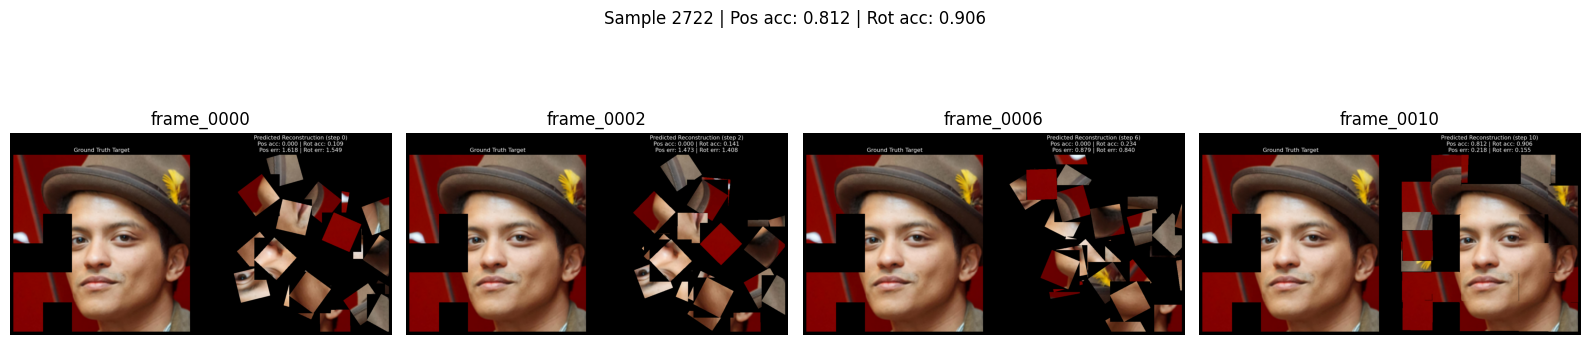

In [273]:
preview_index = 0
sample = saved_samples[preview_index]
frame_paths = sample["frames"]
num_preview = min(4, len(frame_paths))
preview_frames = [frame_paths[idx] for idx in np.linspace(0, len(frame_paths) - 1, num_preview, dtype=int)]

fig, axes = plt.subplots(1, num_preview, figsize=(4 * num_preview, 4))
if num_preview == 1:
    axes = [axes]

for ax, frame_path in zip(axes, preview_frames):
    ax.imshow(imageio.imread(frame_path))
    ax.set_title(frame_path.stem)
    ax.axis("off")

metrics = sample["final_metrics"]
fig.suptitle(
    f"Sample {sample['sample_id']} | "
    f"Pos acc: {metrics['position_accuracy']:.3f} | "
    f"Rot acc: {metrics['rotation_accuracy']:.3f}",
    y=1.02,
 )
fig.tight_layout()
plt.show()